# 02 · Dataset común 2025–2026, partición Out-of-Time y auditoría
Une el S4 reconstruido con los precursores **causalizados** (ver `s4.features`), busca el corte cronológico (por día ionosférico que empieza a las 12 UT = 07 LT) y audita la ausencia de fuga. Las fechas elegidas deben **copiarse al YAML** (`split.fin_train`, `split.fin_validacion`) para que todos los experimentos usen exactamente la misma partición.

In [3]:
import sys, warnings
sys.path.insert(0, "../src")
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from s4.config import cargar_config, variante, ruta
from s4.pipeline import preparar_datos
from s4 import features as ft
cfg = cargar_config('../config/ablacion_2025_2026.yaml')

In [4]:
datos = preparar_datos(cfg)
datos['corte']['ranking']

S4 reconstruido: 1,891,672 obs | 2022-01-01 00:00:00 -> 2026-09-13 14:15:00 | minutos reconstruidos: 15,457 (0.82 %) | flags: ['Fix0', 'Fix1', 'Fix3', 'Fix4', 'Fix_Pico']
  TEC: 70.3 % de minutos rellenados linealmente -> se mantiene el último valor real
  ROTEC: 66.17 % de minutos rellenados linealmente -> se mantiene el último valor real
  ROTI: 66.05 % de minutos rellenados linealmente -> se mantiene el último valor real
  % NaN por columna tras causalizar: {'Kp_Index': 0.02, 'f10.7_Index': 0.2}
Join S4 + precursores: 685,405 filas, 1,391 descartadas por NaN.
✓ Auditoría de fuga: orden estricto TRAIN < VAL < TEST, sin solapamientos y ningún evento partido entre particiones.
 particion              inicio                 fin  observaciones  dias  dias_activos  pct_dias_activos  eventos  minutos_evento
     TRAIN 2025-01-27 00:01:00 2025-12-10 11:59:00         423147   309            64             20.71      361             667
VALIDACIÓN 2025-12-10 12:00:00 2026-03-02 11:59:00      

,rank,fin_train,fin_validacion,train_days,train_active_days,train_events,val_days,val_active_days,val_events,test_days,test_active_days,test_events,ratio_error,activity_error
0,1,2025-12-09,2026-03-01,309,64,361,73,16,116,125,13,253,0.1826,13.89
1,2,2025-12-10,2026-03-01,310,64,361,72,16,116,125,13,253,0.1826,14.12
2,3,2025-12-09,2026-02-28,309,64,361,72,16,116,126,13,253,0.1868,14.27
3,4,2025-12-11,2026-03-01,311,64,361,71,16,116,125,13,253,0.1826,14.37
4,5,2025-12-07,2026-03-01,307,63,356,75,17,121,125,13,253,0.1826,14.44
5,6,2025-12-10,2026-02-28,310,64,361,71,16,116,126,13,253,0.1868,14.52
6,7,2025-12-12,2026-03-01,312,64,361,70,16,116,125,13,253,0.1826,14.63
7,8,2025-12-08,2026-03-01,308,63,356,74,17,121,125,13,253,0.1826,14.68
8,9,2025-12-09,2026-02-27,309,64,361,71,16,116,127,13,253,0.1909,14.67
9,10,2025-12-11,2026-02-28,311,64,361,70,16,116,126,13,253,0.1868,14.78


In [5]:
print("COPIAR AL YAML ->", "fin_train:", datos["corte"]["fin_train"].date(), "| fin_validacion:", datos["corte"]["fin_validacion"].date())
datos["reporte"].to_csv(ruta(cfg, "reportes") / "tables/tabla_particion.csv", index=False)

COPIAR AL YAML -> fin_train: 2025-12-09 | fin_validacion: 2026-03-01


Dst_Index 73.03 % de minutos en tramos lineales
AE_Index 82.87 % de minutos en tramos lineales
TEC 70.3 % de minutos en tramos lineales
ROTI 66.05 % de minutos en tramos lineales


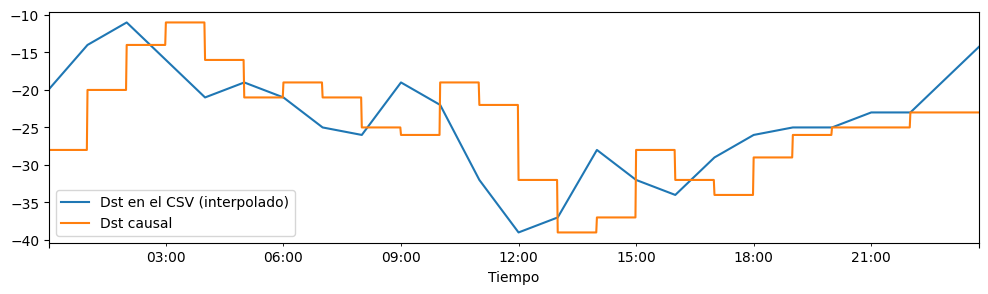

In [6]:
# Diagnóstico de la fuga en los índices interpolados (evidencia para la tesis)
from s4 import io
mv = io.cargar_multivariable(ruta(cfg, "multivariable"))
for c in ["Dst_Index", "AE_Index", "TEC", "ROTI"]:
    print(c, ft.diagnosticar_interpolacion(mv[c])["pct_minutos_lineales"], "% de minutos en tramos lineales")
dia = "2025-03-15"
fig, ax = plt.subplots(figsize=(12, 3))
mv.loc[dia, "Dst_Index"].plot(ax=ax, label="Dst en el CSV (interpolado)")
ft.causalizar_indice(mv["Dst_Index"], "1h").loc[dia].plot(ax=ax, label="Dst causal")
ax.legend(); plt.show()

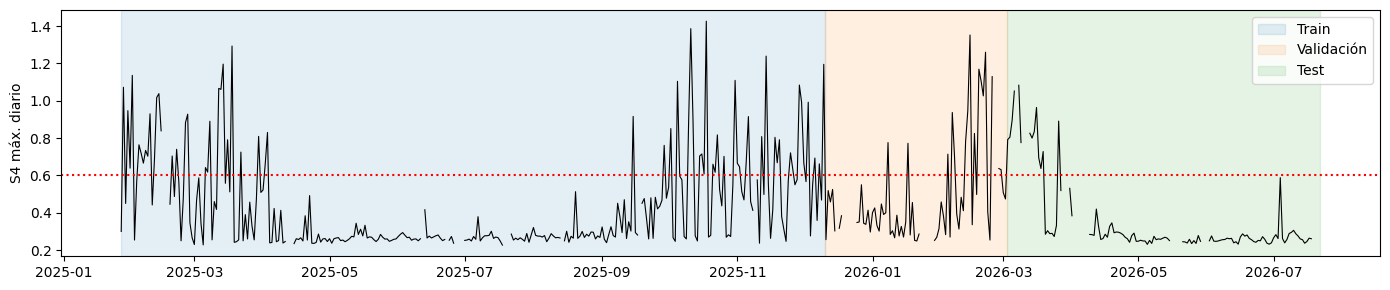

In [7]:
# Mapa temporal de la partición
df, ev = datos["df"], datos["eventos"]
diario = df["S4"].resample("1D").max()
fig, ax = plt.subplots(figsize=(14, 3))
for n, p, c in [("Train", datos["train"], "tab:blue"), ("Validación", datos["val"], "tab:orange"), ("Test", datos["test"], "tab:green")]:
    ax.axvspan(p.index.min(), p.index.max(), color=c, alpha=0.12, label=n)
ax.plot(diario.index, diario.values, color="k", lw=0.8); ax.axhline(0.6, color="r", ls=":")
ax.set_ylabel("S4 máx. diario"); ax.legend(); plt.tight_layout()
plt.savefig(ruta(cfg, "reportes") / "figures/fig_particion_oot.png", dpi=200); plt.show()